In [31]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

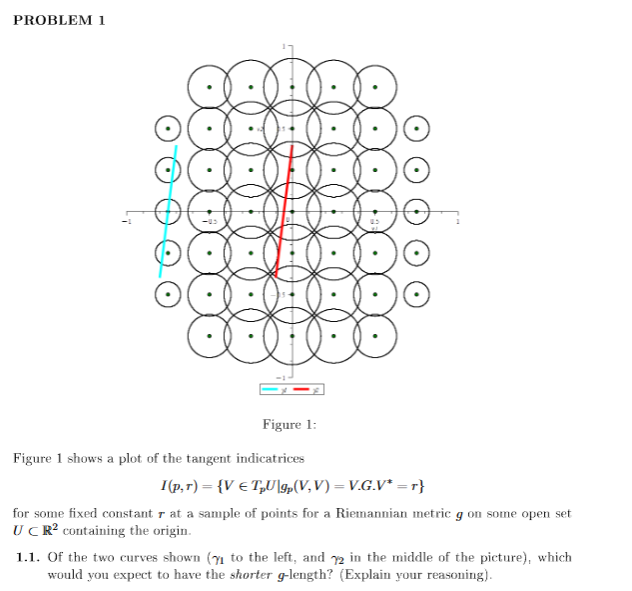

gamma_2 will have the shorter as the circles are bigger

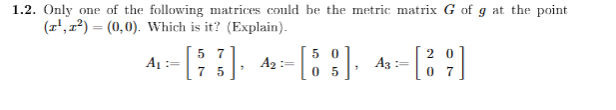

A2 is the onlt one that makes sense as 

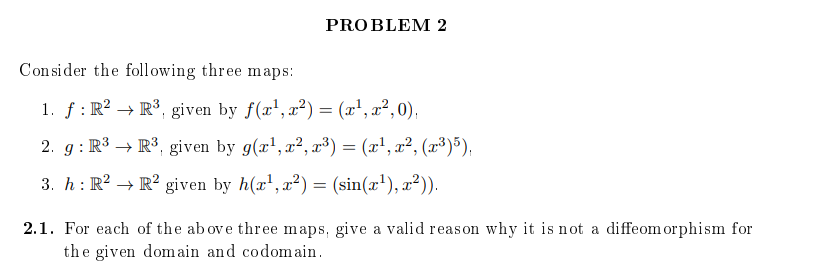

a diffeomorphism has to be quadratic so f cant work

In [32]:
y1, y2, y3, x1, x2, x3 = sp.symbols('y1 y2 y3 x1 x2 x3', real=True)

f = sp.Matrix([x1, x2, 0])
g = sp.Matrix([x1, x2, x3**5])
h = sp.Matrix([sp.sin(x1), x2])

phi = g

J = phi.jacobian([x1, x2, x3])
display(J)

det_J = J.det()
display(det_J)

# If sol is the result of solve
sol = sp.solve([sp.Eq(phi[0], y1), sp.Eq(phi[1], y2), sp.Eq(phi[2], y3)], (x1, x2, x3))


phi_inv = sp.Matrix([sol[0]])
display(phi_inv)

J_inv = phi_inv.jacobian([y1, y2, y3])
display(J_inv)

det_J_inv = J_inv.det()
display(det_J_inv)

Matrix([
[1, 0,       0],
[0, 1,       0],
[0, 0, 5*x3**4]])

5*x3**4

Matrix([[y1, y2, y3**(1/5)]])

Matrix([
[1, 0,               0],
[0, 1,               0],
[0, 0, 1/(5*y3**(4/5))]])

1/(5*y3**(4/5))

So y3 is not defined at equal to 0 and thereby not a diffeomorphism

h does not cover the whole codomain so x1 will be mapped into a domain only between [-1,1]

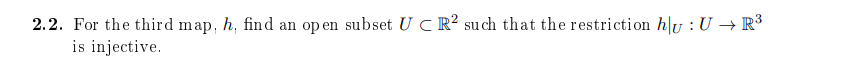

Here an open subset could be $U \in [-\pi/2,\pi/2]$

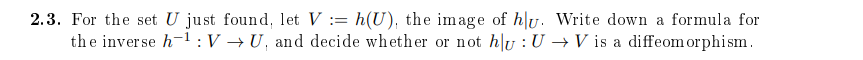

In [33]:
y1, y2, y3, x1, x2, x3 = sp.symbols('y1 y2 y3 x1 x2 x3', real=True)

f = sp.Matrix([x1, x2, 0])
g = sp.Matrix([x1, x2, x3**5])
h = sp.Matrix([sp.sin(x1), x2])

phi = h

J = phi.jacobian([x1, x2])
display(J)

det_J = J.det()
display(det_J)

# If sol is the result of solve
sol = sp.solve([sp.Eq(phi[0], y1), sp.Eq(phi[1], y2)], (x1, x2))
print(sol)
phi_inv = sp.Matrix([sol[1]])
display(phi_inv)

J_inv = phi_inv.jacobian([y1, y2])
display(J_inv)

det_J_inv = J_inv.det()
display(det_J_inv)

Matrix([
[cos(x1), 0],
[      0, 1]])

cos(x1)

[(pi - asin(y1), y2), (asin(y1), y2)]


Matrix([[asin(y1), y2]])

Matrix([
[1/sqrt(1 - y1**2), 0],
[                0, 1]])

1/sqrt(1 - y1**2)

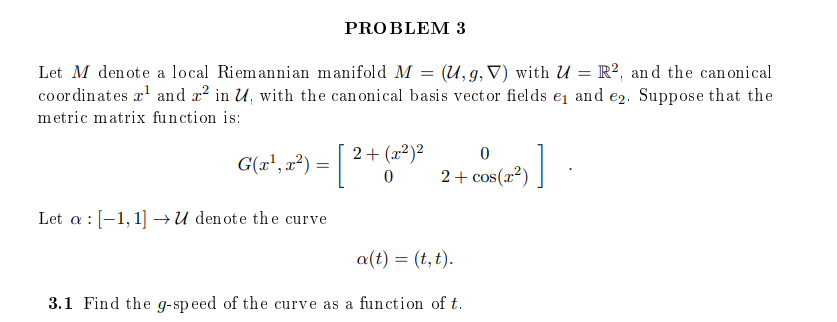

In [40]:
t = sp.symbols('t')

G = sp.Matrix([[2+x2**2,0],[0,2+sp.cos(x2)]])

alpha = sp.Matrix([t,t])

alpha_dot = alpha.diff(t)

speed = DG503.g_norm(G.subs({x1:alpha[0],x2:alpha[1]}),alpha_dot)
display(speed)

sqrt(t**2 + cos(t) + 4)

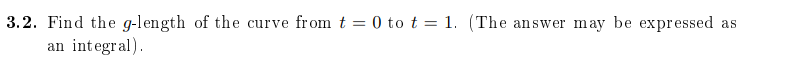

In [48]:
length = sp.integrate(speed,(t,0,1))

display(length.doit())

Integral(sqrt(t**2 + cos(t) + 4), (t, 0, 1))

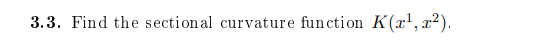

In [51]:
a, b, c, d = sp.symbols('a b c d')

sec_curv = DG503.sectional_curvature(G, [x1,x2], [a,b], [c,d], [x1,x2])

display(sp.simplify(sec_curv))

(-x2**3*sin(x2)/2 - x2*sin(x2) - 2*cos(x2) - 4)/((x2**2 + 2)**2*(cos(x2) + 2)**2)

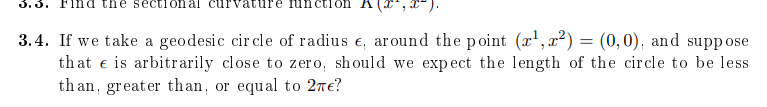

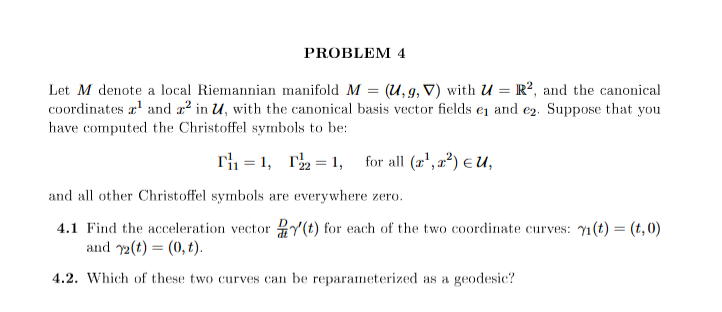

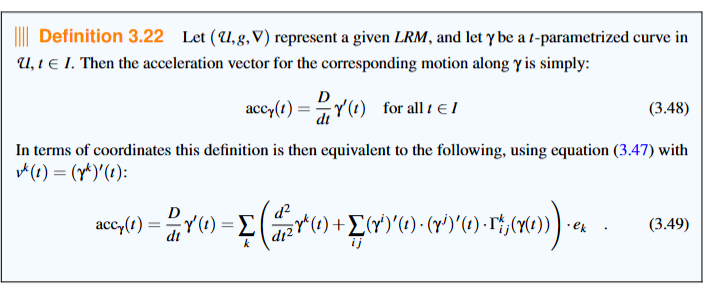

In [ ]:
import sympy as sp

t = sp.symbols('t')

# Define Christoffel symbols as a dictionary for easy lookup
# Gamma[k][i,j] where k, i, j are 0 or 1 (representing coordinates 1 and 2)
Gamma = {0: sp.zeros(2, 2), 1: sp.zeros(2, 2)}
Gamma[0][0, 0] = 1  # Gamma^1_11 = 1
Gamma[0][1, 1] = 1  # Gamma^1_22 = 1

def compute_acceleration(gamma, t, Gamma):
    gamma_dot = gamma.diff(t)
    gamma_ddot = gamma_dot.diff(t)
    acc = sp.zeros(2, 1)
    
    for k in range(2):
        term_sum = 0
        for i in range(2):
            for j in range(2):
                term_sum += gamma_dot[i] * gamma_dot[j] * Gamma[k][i, j]
        acc[k] = gamma_ddot[k] + term_sum
    return acc

# Define curves from image_e8fe9b.png
gamma_1 = sp.Matrix([t, 0])
gamma_2 = sp.Matrix([0, t])

# 4.1 Find the acceleration vectors
acc_gamma_1 = compute_acceleration(gamma_1, t, Gamma)
acc_gamma_2 = compute_acceleration(gamma_2, t, Gamma)

print("Acceleration of gamma_1(t):")
sp.pprint(acc_gamma_1)

print("\nAcceleration of gamma_2(t):")
sp.pprint(acc_gamma_2)

Acceleration of gamma_1(t):
⎡1⎤
⎢ ⎥
⎣0⎦

Acceleration of gamma_2(t):
⎡1⎤
⎢ ⎥
⎣0⎦


: 

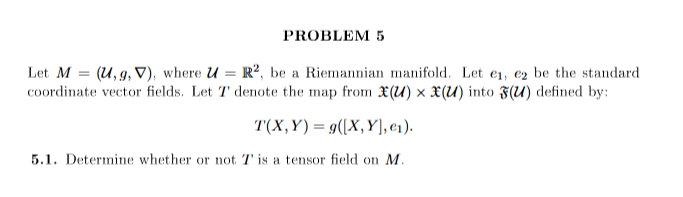

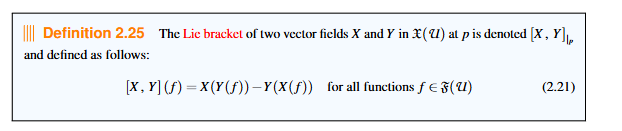